# UFTC B-747 — coordinated banked turn with mid-turn engine failure

This notebook is the **maneuver** counterpart of the stationary-trim Phase 1 / Phase 3 / Phase 4 demos. Instead of holding straight-and-level cruise, the aircraft executes a 90 s coordinated banked-turn schedule:

| Window (s) | Phase | What changes |
|------------|-------|--------------|
| 0 – 5      | level cruise | hold V, h, ψ = 0 |
| 5 – 15     | roll-in      | bank φ ramps 0 → +15° (right bank) |
| 15 – 55    | steady banked turn | φ = +15°, ψ slews at ≈0.73°/s (consistent with `g·tan(φ)/V`) |
| 55 – 65    | roll-out     | φ ramps +15° → 0 |
| 65 – 90    | new-heading hold | φ = 0, ψ = ψ_final |

**Damage**: the **left-outer engine flames out at t = 35 s**, *mid-turn*, so UFTC must keep tracking a slewing reference under asymmetric thrust.

We compare two configurations:
* **Phase 1** — L2 AA-INDI inner + L3 IADP middle + envelope allocator, **no L4 outer, no monitor**.
* **Phase 4** — full UFTC stack: pre-trained L4 D-SAC outer + composite Lyapunov monitor + macro-action dispatcher.

**Plant-agnostic note** — UFTC's reference vector remains `0` throughout. The time-varying maneuver is injected in the *envelope-allocator setpoint* `ref0(t)` that `uftc_state_transform` uses to build the error-form state. UFTC sees a non-trivial drifting error and the cascade compensates online.


## 1. Imports and simulation settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

from tensoraerospace.aerospacemodel.b747.nonlinear import B747Configuration, trim
from tensoraerospace.aerospacemodel.b747.nonlinear.damage.state import B747DamageState
from tensoraerospace.aerospacemodel.b747.nonlinear.dynamics import b747_ode_6dof
from tensoraerospace.aerospacemodel.b747.nonlinear.damage import (
    DamageProfile, EngineFailureEvent,
)
from tensoraerospace.aerospacemodel.b747.nonlinear.engine import JT9DEngine
from tensoraerospace.aerospacemodel.b747.nonlinear.params import (
    default_parameters, isa_speed_of_sound_ft_s,
)
import importlib
import tensoraerospace.agent.uftc.controller as uftc_controller_module
importlib.reload(uftc_controller_module)
from tensoraerospace.agent.uftc.controller import UFTCConfig, UFTCController
from tensoraerospace.agent.aa_indi.model import AAINDIConfig
from tensoraerospace.agent.iadp.model import IADPConfig
from tensoraerospace.agent.uftc.fdd.detector import FDDConfig
from tensoraerospace.envs.b747_nonlinear import NonlinearB747Env

np.random.seed(0)
import torch
torch.manual_seed(0)

DT = 0.05
TOTAL_TIME = 90.0
DAMAGE_TIME = 35.0
N_EP = int(TOTAL_TIME / DT)         # 1800 steps
DAMAGE_STEP = int(DAMAGE_TIME / DT)

V_REF_FT_S = 674.0
ALT_REF_FT = 20_000.0
PSI_REF_DEG = 0.0

# Coordinated-turn schedule. Sign convention: positive bank phi = right wing
# down (right bank). For a coordinated right turn the heading rate satisfies
#   psi_dot = (g/V) * tan(phi),  positive bank -> positive psi rate.
TURN_BANK_DEG  = 15.0     # peak bank angle (right turn -> positive bank)
TURN_BANK_SIGN = +1.0     # right turn
ROLL_IN_S   = (5.0, 15.0)
STEADY_S    = (15.0, 55.0)
ROLL_OUT_S  = (55.0, 65.0)

print(f"Episode horizon : {TOTAL_TIME:.0f} s ({N_EP} steps @ dt={DT}s)")
print(f"Damage trigger  : t = {DAMAGE_TIME:.0f} s (step {DAMAGE_STEP})")
print(f"Turn schedule   : roll-in {ROLL_IN_S}, steady {STEADY_S}, roll-out {ROLL_OUT_S}")
print(f"Peak bank       : {TURN_BANK_SIGN*TURN_BANK_DEG:+.1f} deg (right bank)")


Episode horizon : 90 s (1800 steps @ dt=0.05s)
Damage trigger  : t = 35 s (step 700)
Turn schedule   : roll-in (5.0, 15.0), steady (15.0, 55.0), roll-out (55.0, 65.0)
Peak bank       : +15.0 deg (right bank)


## 2. Cruise and one-engine-out trim

Same trim solve as Phase 4: a healthy cruise trim plus a static left-outer-engine-out trim that the envelope allocator blends into during the failure transient. The blend coefficient is `engine_loss_estimate ∈ [0, 1]` driven by the FDD severity output.


In [2]:
trim_result = trim(altitude_ft=ALT_REF_FT, V_ft_s=V_REF_FT_S,
                   config=B747Configuration.NOMINAL)
assert trim_result.converged

delta_e_trim_rad = float(trim_result.elevator_rad)
throttle_trim = float(trim_result.throttle)
theta_ref_deg = math.degrees(trim_result.theta_rad)
healthy_trim_action = np.array([
    delta_e_trim_rad, 0.0, 0.0, throttle_trim,
], dtype=np.float64)

engine_params = default_parameters(B747Configuration.NOMINAL)
engine_model = JT9DEngine(
    n_engines=4,
    sls_thrust_per_engine_lb=engine_params.engine_thrust_max_lb / 4.0,
    idle_frac=engine_params.engine_idle_frac,
    spool_tau_s=engine_params.engine_tau_s,
)

engine_out_params = default_parameters(B747Configuration.NOMINAL)
engine_out_damage_state = B747DamageState.healthy()
engine_out_damage_state.engines_mu[1] = 0.0
engine_out_params.damage_state = engine_out_damage_state
throttle_engine_out_estimate = min(throttle_trim * 4.0 / 3.0, 1.0)

def engine_out_state_from_vars(alpha_rad, beta_rad, theta_rad):
    return np.array([
        V_REF_FT_S * math.cos(alpha_rad) * math.cos(beta_rad),
        V_REF_FT_S * math.sin(beta_rad),
        V_REF_FT_S * math.sin(alpha_rad) * math.cos(beta_rad),
        0.0, 0.0, 0.0,
        0.0, theta_rad, 0.0,
        0.0, 0.0, -ALT_REF_FT,
    ], dtype=np.float64)

def engine_out_trim_residual(z):
    alpha_rad, beta_rad, theta_rad, de_rad, da_rad, dr_rad, throttle_cmd = z
    x = engine_out_state_from_vars(alpha_rad, beta_rad, theta_rad)
    u = np.array([de_rad, da_rad, dr_rad, np.clip(throttle_cmd, 0.0, 1.0)],
                 dtype=np.float64)
    dx = b747_ode_6dof(x, u, 0.0, engine_out_params)
    return np.array([dx[0], dx[1], dx[2], dx[3], dx[4], dx[5], dx[11]], dtype=np.float64)

z0 = np.array([trim_result.alpha_rad, math.radians(-0.44), trim_result.theta_rad,
               delta_e_trim_rad, math.radians(-4.4), math.radians(-2.64),
               throttle_engine_out_estimate], dtype=np.float64)
engine_out_solution, info, ier, msg = fsolve(
    engine_out_trim_residual, z0, full_output=True, xtol=1e-10, maxfev=2_000,
)
engine_out_residual_norm = float(np.linalg.norm(info["fvec"]))
assert ier == 1 and engine_out_residual_norm < 1e-6, msg

(alpha_engine_out_rad, beta_engine_out_rad, theta_engine_out_rad,
 delta_e_engine_out_rad, delta_a_engine_out_rad, delta_r_engine_out_rad,
 throttle_engine_out) = engine_out_solution
throttle_engine_out = float(np.clip(throttle_engine_out, 0.0, 1.0))
engine_out_trim_action = np.array([
    delta_e_engine_out_rad, delta_a_engine_out_rad,
    delta_r_engine_out_rad, throttle_engine_out,
], dtype=np.float64)

print(f"Healthy trim @ FL200, V={V_REF_FT_S:.0f} ft/s:")
print(f"  alpha = theta = {theta_ref_deg:+.3f} deg")
print(f"  delta_e_trim  = {math.degrees(delta_e_trim_rad):+.3f} deg, throttle_trim = {throttle_trim:.4f}")
print(f"Engine-out trim residual norm = {engine_out_residual_norm:.2e}")


Healthy trim @ FL200, V=674 ft/s:
  alpha = theta = +3.603 deg
  delta_e_trim  = -0.722 deg, throttle_trim = 0.5549
Engine-out trim residual norm = 8.27e-15


## 3. Reference schedule — coordinated banked turn

Build a `reference_schedule(t)` returning a target dict `{V, h, theta, psi, phi, beta}`. The bank schedule is a trapezoidal ramp; the heading schedule is the analytic integral of the coordinated-turn rate ψ̇ ≈ g·tan(|φ|) / V over the same window.

Numbers (chosen for a clean-looking maneuver, not maximum aggression):
* Bank: peak +15° (right bank).
* Roll rate: ±1.5 °/s during ramps.
* Steady-turn ψ̇ ≈ g·tan(15°) / V ≈ 32.17·0.268 / 674 ≈ 0.0128 rad/s ≈ **0.732 °/s**.
* Total Δψ ≈ 0.5·1.5·10 (ramp-in) + 0.732·40 (steady) + 0.5·1.5·10 (ramp-out) ≈ 7.5 + 29.3 + 7.5 ≈ **44.3°**.

θ gets a small +0.3° offset during the turn to compensate for the lift-vector tilt at 15° bank (`L·cos(φ)`-style proxy). β reference stays at 0 in the un-failed phase and blends toward the engine-out β trim post-failure.


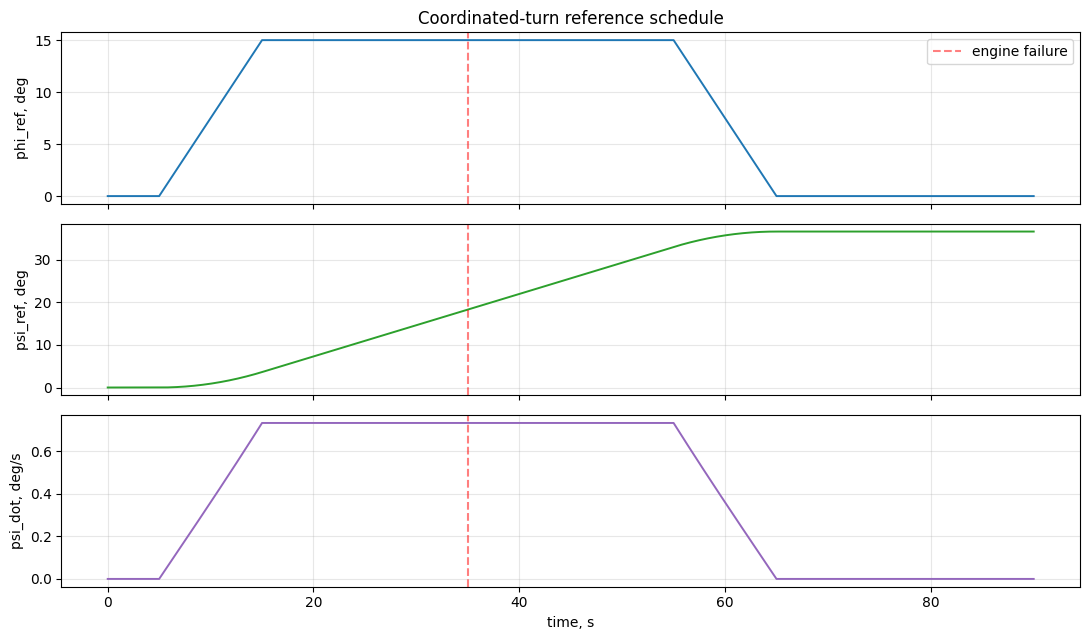

Total heading change Δψ over schedule = +36.55 deg
Steady-turn psi_dot at peak bank      = +0.733 deg/s


In [3]:
G_FT_S2 = 32.17

def _phi_ref_rad(t: float) -> float:
    if t < ROLL_IN_S[0]:
        return 0.0
    if t < ROLL_IN_S[1]:
        frac = (t - ROLL_IN_S[0]) / (ROLL_IN_S[1] - ROLL_IN_S[0])
        return TURN_BANK_SIGN * math.radians(TURN_BANK_DEG) * frac
    if t < STEADY_S[1]:
        return TURN_BANK_SIGN * math.radians(TURN_BANK_DEG)
    if t < ROLL_OUT_S[1]:
        frac = 1.0 - (t - ROLL_OUT_S[0]) / (ROLL_OUT_S[1] - ROLL_OUT_S[0])
        return TURN_BANK_SIGN * math.radians(TURN_BANK_DEG) * frac
    return 0.0

def _psi_dot_coordinated(phi_rad: float, V_ft_s: float) -> float:
    # Coordinated turn: psi_dot = (g/V) * tan(phi).
    # Positive bank (right wing down) -> positive psi rate (right turn).
    return G_FT_S2 * math.tan(phi_rad) / max(V_ft_s, 1.0)

# Pre-compute psi_ref(t) by trapezoidal integration of psi_dot(phi_ref(t), V_REF).
_t_grid = np.arange(0.0, TOTAL_TIME + DT, DT)
_phi_grid = np.array([_phi_ref_rad(float(t)) for t in _t_grid])
_psi_dot_grid = np.array([_psi_dot_coordinated(float(p), V_REF_FT_S) for p in _phi_grid])
_psi_grid = np.zeros_like(_t_grid)
for i in range(1, len(_t_grid)):
    _psi_grid[i] = _psi_grid[i-1] + 0.5 * DT * (_psi_dot_grid[i-1] + _psi_dot_grid[i])
PSI_FINAL_RAD = float(_psi_grid[int(ROLL_OUT_S[1] / DT)])

def _psi_ref_rad(t: float) -> float:
    if t <= 0.0:
        return 0.0
    if t >= ROLL_OUT_S[1]:
        return PSI_FINAL_RAD
    return float(np.interp(t, _t_grid, _psi_grid))

def _theta_offset_rad(t: float) -> float:
    if STEADY_S[0] - 1.0 < t < STEADY_S[1] + 1.0:
        return math.radians(0.3)
    return 0.0

def reference_schedule(t: float, beta_target_rad: float = 0.0) -> dict:
    return {
        "V": V_REF_FT_S,
        "h": ALT_REF_FT,
        "theta": float(trim_result.theta_rad) + _theta_offset_rad(t),
        "psi": _psi_ref_rad(t),
        "phi": _phi_ref_rad(t),
        "beta": beta_target_rad,
    }

# Visualise the reference
phi_ref_deg = np.degrees(_phi_grid)
psi_ref_deg = np.degrees(_psi_grid)
psi_dot_deg_s = np.degrees(_psi_dot_grid)

fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
axes[0].plot(_t_grid, phi_ref_deg, color='tab:blue', lw=1.4)
axes[0].axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5, label='engine failure')
axes[0].set_ylabel('phi_ref, deg'); axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].plot(_t_grid, psi_ref_deg, color='tab:green', lw=1.4)
axes[1].axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5)
axes[1].set_ylabel('psi_ref, deg'); axes[1].grid(True, alpha=0.3)
axes[2].plot(_t_grid, psi_dot_deg_s, color='tab:purple', lw=1.4)
axes[2].axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5)
axes[2].set_xlabel('time, s'); axes[2].set_ylabel('psi_dot, deg/s'); axes[2].grid(True, alpha=0.3)
axes[0].set_title('Coordinated-turn reference schedule')
plt.tight_layout(); plt.show()
print(f'Total heading change Δψ over schedule = {math.degrees(PSI_FINAL_RAD):+.2f} deg')
print(f'Steady-turn psi_dot at peak bank      = '
      f'{math.degrees(_psi_dot_coordinated(TURN_BANK_SIGN*math.radians(TURN_BANK_DEG), V_REF_FT_S)):+.3f} deg/s')


## 4. Damage profile — engine failure at t = 35 s

The stock `LEFT_OUTER_ENGINE_FAILURE` preset triggers the failure at t = 10 s. We construct a local `DamageProfile` with the same `EngineFailureEvent` parameters but `trigger_time=DAMAGE_TIME=35 s`.


In [4]:
TURN_ENGINE_FAILURE = DamageProfile(
    events=[
        EngineFailureEvent(
            trigger_time=DAMAGE_TIME,
            engine_id=1,
            thrust_fraction=0.0,
            label='left_outer_engine_flameout_mid_turn',
        ),
    ],
)
print(f'Damage profile: {TURN_ENGINE_FAILURE.events[0]}')


Damage profile: EngineFailureEvent(trigger_time=35.0, engine_id=1, thrust_fraction=0.0, label='left_outer_engine_flameout_mid_turn')


## 5. UFTC controller and helpers

The UFTC state remains `[eV, eh, e_theta, e_psi, e_phi, e_beta, p, q, r]` — exactly as in the Phase 4 demo. The only change: `uftc_state_transform` now takes a **time-varying** setpoint `ref_t` instead of a frozen `ref0`. Everything downstream stays the same.


In [5]:
UFTC_RESIDUAL_SCALE = np.array([
    0.0,
    math.radians(0.05),
    math.radians(0.05),
    0.0,
], dtype=np.float64)

UFTC_STATE_SCALE = np.array([
    25.0, 250.0,
    math.radians(3.0), math.radians(8.0),
    math.radians(8.0), math.radians(2.0),
    1.0, 1.0, 1.0,
], dtype=np.float64)
N_UFTC_STATE = int(UFTC_STATE_SCALE.size)
UFTC_OMEGA_INDICES = [6, 7, 8]
UFTC_REFERENCE = np.zeros(N_UFTC_STATE, dtype=np.float64)

UFTC_F_INIT = np.eye(N_UFTC_STATE, dtype=np.float64) * 0.99
UFTC_F_INIT[2, 7] = DT / UFTC_STATE_SCALE[2]
UFTC_F_INIT[3, 8] = DT / UFTC_STATE_SCALE[3]
UFTC_F_INIT[4, 6] = DT / UFTC_STATE_SCALE[4]

UFTC_G_INIT = np.zeros((N_UFTC_STATE, 4), dtype=np.float64)
UFTC_G_INIT[0] = [0.0, 0.0, 0.0, 0.08]
UFTC_G_INIT[1] = [-0.02, 0.0, 0.0, 0.03]
UFTC_G_INIT[6] = [0.00, 0.30, 0.00, 0.00]
UFTC_G_INIT[7] = [0.40, 0.00, 0.00, 0.10]
UFTC_G_INIT[8] = [0.00, 0.05, 0.30, 0.00]
UFTC_G_INNER = UFTC_G_INIT[UFTC_OMEGA_INDICES].copy()

L4_ACTION_SCALE = 0.05
L4_TRIM_FREE_INDICES = {'V_idx': 0, 'gamma_idx': 1, 'alpha_idx': 2, 'q_idx': 7}

# Phase 4 monitor calibration — relaxed d=(80,)*5 to keep the alarm meaningful
# during a long maneuver that already drives V_INDI/V_FDD higher.
MONITOR_CFG = dict(
    enable_monitor=True,
    monitor_c_weights=(0.0, 0.4, 0.0, 0.3, 0.3),
    monitor_d_disturbance=(80.0,) * 5,
    monitor_alarm_warn_frac=0.4,
    monitor_alarm_critical_frac=0.7,
    monitor_cooldown_steps=20,
)

def make_env(damage_profile=None, n_steps=N_EP + 5):
    return NonlinearB747Env(
        trim_at=(ALT_REF_FT, V_REF_FT_S),
        number_time_steps=n_steps,
        dt=DT, integrator='rk4', action_space='virtual',
        config=B747Configuration.NOMINAL,
        damage_profile=damage_profile,
    )

def make_controller(*, enable_l4_outer=True, enable_trim_free=True,
                    enable_monitor=True):
    cfg_kwargs = dict(
        dt=DT,
        fdd_warmup_steps=0,
        omega_indices=UFTC_OMEGA_INDICES,
        middle_lookahead_dt=0.3,
        trust_radius_nominal=0.03,
        trust_radius_fault=0.15,
        fdd_cfg=FDDConfig(process_noise=1e-4, measurement_noise=1e-3,
                          adapt_Q=False, adapt_R=False, drift=6.0, h_alarm=15.0),
        inner_cfg=AAINDIConfig(dt=DT, ref_wn=3.0, ref_zeta=0.9,
                               u_magnitude_limit=1.0, u_rate_limit=5.0,
                               G_init=UFTC_G_INNER, ref_error_kp=2.0,
                               ref_error_ki=0.05, seed=0),
        middle_cfg=IADPConfig(dt=DT,
                              Q=np.diag([20., 40., 20., 20., 20., 0.5, 2., 2., 2.]),
                              R=np.diag([8., 8., 8., 20.]),
                              gamma=0.85, gamma_rls=0.995,
                              u_magnitude_limit=1.0, u_rate_limit=4.0,
                              policy_eval_every=80, policy_eval_blend=0.15),
        enable_l4_outer=bool(enable_l4_outer),
        l4_action_scale=L4_ACTION_SCALE,
        l4_eval_mode=True,
        l4_seed=0,
        l4_trim_free=(L4_TRIM_FREE_INDICES if enable_trim_free else None),
    )
    if enable_monitor:
        cfg_kwargs.update(MONITOR_CFG)
    return UFTCController(
        n_state=N_UFTC_STATE, n_control=4,
        nominal_F=UFTC_F_INIT, nominal_G=UFTC_G_INIT,
        config=UFTCConfig(**cfg_kwargs),
    )


In [6]:
STATE_FEEDBACK_GAINS = {
    'de_h': 1.0e-4,
    'de_theta': 1.5,
    'de_q': 1.0,
    'throttle_v': -3.0e-3,
    'throttle_h': -1.0e-4,
    'da_phi': -2.5,
    'da_p': -1.5,
    'dr_r': 3.0,
    'dr_psi': 1.5,
    'dr_beta': -0.5,
}

def wrap_deg(angle_deg):
    return (float(angle_deg) + 180.0) % 360.0 - 180.0

def wrap_rad(angle_rad):
    return (float(angle_rad) + math.pi) % (2.0 * math.pi) - math.pi

def true_airspeed_ft_s(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return float(np.linalg.norm(obs[:3]))

def altitude_ft(obs):
    return float(-np.asarray(obs, dtype=np.float64).reshape(-1)[11])

def body_sideslip_rad(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    v = max(true_airspeed_ft_s(obs), 1.0)
    return float(math.asin(np.clip(obs[1] / v, -1.0, 1.0)))

def engine_mu_from_info(info):
    damage_state = info.get('damage_state', {}) if isinstance(info, dict) else {}
    em = damage_state.get('engines_mu', {}) if isinstance(damage_state, dict) else {}
    return {eid: float(em.get(eid, em.get(str(eid), 1.0))) for eid in (1,2,3,4)}

def engine_loss_from_info(info, fallback=0.0):
    em = engine_mu_from_info(info)
    if not em:
        return float(fallback)
    return float(np.clip(1.0 - em.get(1, 1.0), 0.0, 1.0))

def per_engine_thrust_lb(obs, throttle, em):
    h = altitude_ft(obs)
    mach = true_airspeed_ft_s(obs) / isa_speed_of_sound_ft_s(h)
    cluster = engine_model.installed_thrust(mach=mach, altitude_ft=h, throttle=throttle)
    per = cluster / 4.0
    return np.array([per * float(em.get(eid, 1.0)) for eid in (1,2,3,4)], dtype=np.float64)

def trim_action_for_loss(loss):
    f = float(np.clip(loss, 0.0, 1.0))
    return (1.0 - f) * healthy_trim_action + f * engine_out_trim_action

def clip_physical_action(action):
    a = np.asarray(action, dtype=np.float64).reshape(4)
    return np.array([
        np.clip(a[0], -math.radians(25.0), math.radians(25.0)),
        np.clip(a[1], -math.radians(20.0), math.radians(20.0)),
        np.clip(a[2], -math.radians(25.0), math.radians(25.0)),
        np.clip(a[3], 0.0, 1.0),
    ], dtype=np.float64)

def uftc_state_transform_dyn(obs, ref_t, engine_loss_estimate):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    loss = float(np.clip(engine_loss_estimate, 0.0, 1.0))
    beta_target = (1.0 - loss) * ref_t['beta'] + loss * beta_engine_out_rad
    raw = np.array([
        true_airspeed_ft_s(obs) - ref_t['V'],
        altitude_ft(obs) - ref_t['h'],
        wrap_rad(obs[7] - ref_t['theta']),
        wrap_rad(obs[8] - ref_t['psi']),
        wrap_rad(obs[6] - ref_t['phi']),
        body_sideslip_rad(obs) - beta_target,
        obs[3], obs[4], obs[5],
    ], dtype=np.float64)
    return raw / UFTC_STATE_SCALE

def state_feedback_action_dyn(x_uftc, ref_t, engine_loss_estimate):
    x = np.asarray(x_uftc, dtype=np.float64).reshape(N_UFTC_STATE)
    v_err, h_err = x[0]*UFTC_STATE_SCALE[0], x[1]*UFTC_STATE_SCALE[1]
    theta_err = x[2]*UFTC_STATE_SCALE[2]
    psi_err = x[3]*UFTC_STATE_SCALE[3]
    phi_err = x[4]*UFTC_STATE_SCALE[4]
    beta_err = x[5]*UFTC_STATE_SCALE[5]
    p, q, r = x[6], x[7], x[8]
    action = trim_action_for_loss(engine_loss_estimate)
    action[0] += (STATE_FEEDBACK_GAINS['de_h']*h_err
                  + STATE_FEEDBACK_GAINS['de_theta']*theta_err
                  + STATE_FEEDBACK_GAINS['de_q']*q)
    action[1] += STATE_FEEDBACK_GAINS['da_phi']*phi_err + STATE_FEEDBACK_GAINS['da_p']*p
    action[2] += (STATE_FEEDBACK_GAINS['dr_r']*r
                  + STATE_FEEDBACK_GAINS['dr_psi']*psi_err
                  + STATE_FEEDBACK_GAINS['dr_beta']*beta_err)
    action[3] += STATE_FEEDBACK_GAINS['throttle_v']*v_err + STATE_FEEDBACK_GAINS['throttle_h']*h_err
    return clip_physical_action(action)

def compose_action(state_feedback, uftc_action_norm):
    residual = UFTC_RESIDUAL_SCALE * np.clip(
        np.asarray(uftc_action_norm, dtype=np.float64).reshape(4), -1.0, 1.0)
    return clip_physical_action(np.asarray(state_feedback, dtype=np.float64).reshape(4) + residual)


## 6. Pre-trained L4 D-SAC weights (optional)

Load `actor.pt` / `critic*.pt` / `target*.pt` from `artifacts/dsac/b747_engine_out_v1/` if available, otherwise fall back to a random-init actor with a printed note.

**Caveat**: those weights were trained on the stationary-trim engine-out task, *not* on a banked turn. The actor will give degraded performance during the maneuver — that's an honest result and a curriculum-extension argument, not a stack failure.


In [7]:
from tensoraerospace.agent.uftc.l4.dsac import DSACOuter

_REL = Path('artifacts/dsac/b747_engine_out_v1')
_candidates = [_REL]
_cwd = Path.cwd().resolve()
for parent in [_cwd, *_cwd.parents]:
    cand = parent / _REL
    if cand not in _candidates:
        _candidates.append(cand)
weights_path = None
for cand in _candidates:
    if cand.exists() and (cand / 'actor.pt').exists():
        weights_path = cand
        break
PRETRAINED_AVAILABLE = weights_path is not None

def _load_pretrained_into(ctl_target):
    pretrained = DSACOuter.from_pretrained(weights_path)
    ctl_target.l4.actor.load_state_dict(pretrained.actor.state_dict())
    ctl_target.l4.critic1.load_state_dict(pretrained.critic1.state_dict())
    ctl_target.l4.critic2.load_state_dict(pretrained.critic2.state_dict())
    ctl_target.l4.target1.load_state_dict(pretrained.target1.state_dict())
    ctl_target.l4.target2.load_state_dict(pretrained.target2.state_dict())

if PRETRAINED_AVAILABLE:
    print(f'Pre-trained L4 weights found at {weights_path}')
else:
    print('No pre-trained L4 weights found - using random-init actor (eval_mode demonstration)')


Pre-trained L4 weights found at /home/mr8bit/Projects/TensorAeroSpace/artifacts/dsac/b747_engine_out_v1


## 7. Closed-loop rollout helper

`run_uftc_episode_turn(damage_profile, ctl)` follows the Phase 4 rollout pattern but feeds the time-varying reference into `uftc_state_transform_dyn` and `state_feedback_action_dyn`. UFTC's `reference` argument stays at zero; the time-varying reference enters through the envelope-allocator setpoint.


In [8]:
def run_uftc_episode_turn(damage_profile, *, ctl):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    ctl.reset()
    engine_loss_estimate = 0.0

    log_keys = [
        'V', 'h', 'theta', 'psi', 'phi', 'beta',
        'V_actual', 'h_actual', 'theta_actual', 'psi_actual', 'phi_actual',
        'V_ref', 'h_ref', 'theta_ref', 'psi_ref', 'phi_ref', 'beta_ref',
        'p', 'q', 'r',
        'de', 'da', 'dr', 'throttle',
        'engine_loss_estimate',
        'T1','T2','T3','T4','T_total',
        'severity', 'fault_present', 'rls_gamma', 'innovation_norm',
        'l4_beta', 'l4_replay_size', 'l4_r_eff_norm',
        'V_total', 'V_hj', 'V_indi', 'V_iadp', 'V_dsac', 'V_fdd',
        'alarm_level', 'mu_uub_pred',
    ]
    logs = {k: np.zeros(N_EP, dtype=np.float64) for k in log_keys}
    t_axis = np.arange(N_EP, dtype=np.float64) * DT
    macro_events = []
    alarm_trans = []
    prev_alarm = 'OK'

    for k in range(N_EP - 2):
        t_now = t_axis[k]
        ref_t = reference_schedule(float(t_now))
        x_uftc = uftc_state_transform_dyn(obs, ref_t, engine_loss_estimate)
        feedback_action = state_feedback_action_dyn(x_uftc, ref_t, engine_loss_estimate)
        u_norm = ctl.predict(x_uftc, UFTC_REFERENCE, time_step=k)
        action = compose_action(feedback_action, u_norm)

        obs, _, _, trunc, info = env.step(action)
        engine_loss_estimate = engine_loss_from_info(info, fallback=engine_loss_estimate)
        ref_next = reference_schedule(float(t_axis[k+1] if k+1 < N_EP else t_now))
        next_x_uftc = uftc_state_transform_dyn(obs, ref_next, engine_loss_estimate)
        ctl.learn(next_x_uftc, UFTC_REFERENCE, time_step=k)

        diag = ctl.diagnostics()
        l4_diag = diag.get('l4', {})
        mon_out = getattr(ctl, '_monitor_out', None)
        if mon_out is not None:
            v_hj = float(mon_out.components.V_hj)
            v_indi = float(mon_out.components.V_indi)
            v_iadp = float(mon_out.components.V_iadp)
            v_dsac = float(mon_out.components.V_dsac)
            v_fdd = float(mon_out.components.V_fdd)
            v_total = float(mon_out.V_total)
            mu_pred = float(mon_out.mu_uub_pred)
            cur_alarm = str(mon_out.alarm)
            for ma in mon_out.interventions:
                macro_events.append((k, t_axis[k], str(ma.kind), dict(ma.payload)))
            if cur_alarm != prev_alarm:
                alarm_trans.append((k, t_axis[k], prev_alarm, cur_alarm))
                prev_alarm = cur_alarm
        else:
            v_hj = v_indi = v_iadp = v_dsac = v_fdd = 0.0
            v_total = 0.0; mu_pred = 0.0; cur_alarm = 'OK'
        alarm_int = {'OK': 0, 'WARN': 1, 'CRITICAL': 2}.get(cur_alarm, 0)

        v_actual = true_airspeed_ft_s(obs)
        h_actual = altitude_ft(obs)
        theta_actual = math.degrees(obs[7])
        psi_actual = wrap_deg(math.degrees(obs[8]))
        phi_actual = math.degrees(obs[6])
        beta_actual = math.degrees(body_sideslip_rad(obs))

        # Log errors versus the time-varying reference (use ref_t at this step).
        logs['V'][k] = v_actual - ref_t['V']
        logs['h'][k] = h_actual - ref_t['h']
        logs['theta'][k] = math.degrees(wrap_rad(obs[7] - ref_t['theta']))
        logs['psi'][k] = math.degrees(wrap_rad(obs[8] - ref_t['psi']))
        logs['phi'][k] = math.degrees(wrap_rad(obs[6] - ref_t['phi']))
        logs['beta'][k] = beta_actual - math.degrees(ref_t['beta'])

        logs['V_actual'][k] = v_actual
        logs['h_actual'][k] = h_actual
        logs['theta_actual'][k] = theta_actual
        logs['psi_actual'][k] = psi_actual
        logs['phi_actual'][k] = phi_actual
        logs['V_ref'][k] = ref_t['V']
        logs['h_ref'][k] = ref_t['h']
        logs['theta_ref'][k] = math.degrees(ref_t['theta'])
        logs['psi_ref'][k] = math.degrees(ref_t['psi'])
        logs['phi_ref'][k] = math.degrees(ref_t['phi'])
        logs['beta_ref'][k] = math.degrees(ref_t['beta'])
        logs['p'][k] = math.degrees(obs[3])
        logs['q'][k] = math.degrees(obs[4])
        logs['r'][k] = math.degrees(obs[5])
        logs['de'][k] = math.degrees(action[0])
        logs['da'][k] = math.degrees(action[1])
        logs['dr'][k] = math.degrees(action[2])
        logs['throttle'][k] = float(action[3])
        logs['engine_loss_estimate'][k] = engine_loss_estimate
        thr = per_engine_thrust_lb(obs, float(action[3]), engine_mu_from_info(info))
        logs['T1'][k], logs['T2'][k], logs['T3'][k], logs['T4'][k] = thr
        logs['T_total'][k] = float(np.sum(thr))
        logs['severity'][k] = float(diag['severity'])
        logs['fault_present'][k] = float(diag['fault_present'])
        logs['rls_gamma'][k] = float(diag['rls_gamma'])
        logs['innovation_norm'][k] = float(diag['innovation_norm'])
        logs['l4_beta'][k] = float(l4_diag.get('beta_t', 0.0))
        logs['l4_replay_size'][k] = float(l4_diag.get('replay_size', 0))
        last_r_eff = getattr(ctl, '_last_r_eff', None)
        if last_r_eff is not None:
            logs['l4_r_eff_norm'][k] = float(np.linalg.norm(last_r_eff))
        logs['V_total'][k] = v_total
        logs['V_hj'][k] = v_hj
        logs['V_indi'][k] = v_indi
        logs['V_iadp'][k] = v_iadp
        logs['V_dsac'][k] = v_dsac
        logs['V_fdd'][k] = v_fdd
        logs['alarm_level'][k] = float(alarm_int)
        logs['mu_uub_pred'][k] = mu_pred
        if trunc:
            break

    n = k + 1
    out = {key: vals[:n] for key, vals in logs.items()}
    out['t'] = t_axis[:n]
    out['macro_events'] = macro_events
    out['alarm_transitions'] = alarm_trans
    return out


## 8. Run two configurations

* **Phase 1**: `enable_l4_outer=False, enable_monitor=False` — L1 shield disabled (placeholder), L2 + L3 + envelope allocator only.
* **Phase 4**: full stack + pre-trained L4 + composite Lyapunov monitor with relaxed `d=(80,)*5` calibration.


In [9]:
ctl_p1 = make_controller(enable_l4_outer=False, enable_trim_free=False,
                         enable_monitor=False)
log_p1 = run_uftc_episode_turn(TURN_ENGINE_FAILURE, ctl=ctl_p1)
print(f'Phase 1 rollout: {len(log_p1["t"])} steps, final t = {log_p1["t"][-1]:.2f} s')

ctl_p4 = make_controller(enable_l4_outer=True, enable_trim_free=True,
                         enable_monitor=True)
if PRETRAINED_AVAILABLE:
    _load_pretrained_into(ctl_p4)
    print(f'Phase 4: loaded pre-trained L4 weights from {weights_path}')
else:
    print('Phase 4: random-init L4 actor (no pre-trained weights)')
if ctl_p4.monitor is not None:
    print(f'Phase 4 monitor mu_uub_pred = {ctl_p4.monitor.mu_uub_pred:.4f}')
log_p4 = run_uftc_episode_turn(TURN_ENGINE_FAILURE, ctl=ctl_p4)
print(f'Phase 4 rollout: {len(log_p4["t"])} steps, final t = {log_p4["t"][-1]:.2f} s')


Phase 1 rollout: 1798 steps, final t = 89.85 s


Phase 4: loaded pre-trained L4 weights from /home/mr8bit/Projects/TensorAeroSpace/artifacts/dsac/b747_engine_out_v1
Phase 4 monitor mu_uub_pred = 266.6667


Phase 4 rollout: 1798 steps, final t = 89.85 s


## 9. Reference vs actual — six-panel tracking comparison

Each panel: reference (dashed black), Phase 1 actual (gray), Phase 4 actual (blue). The vertical red line marks the engine failure at t = 35 s. The bank-angle and heading panels are the most informative — they show the aircraft executing the turn through the failure event in both configurations.


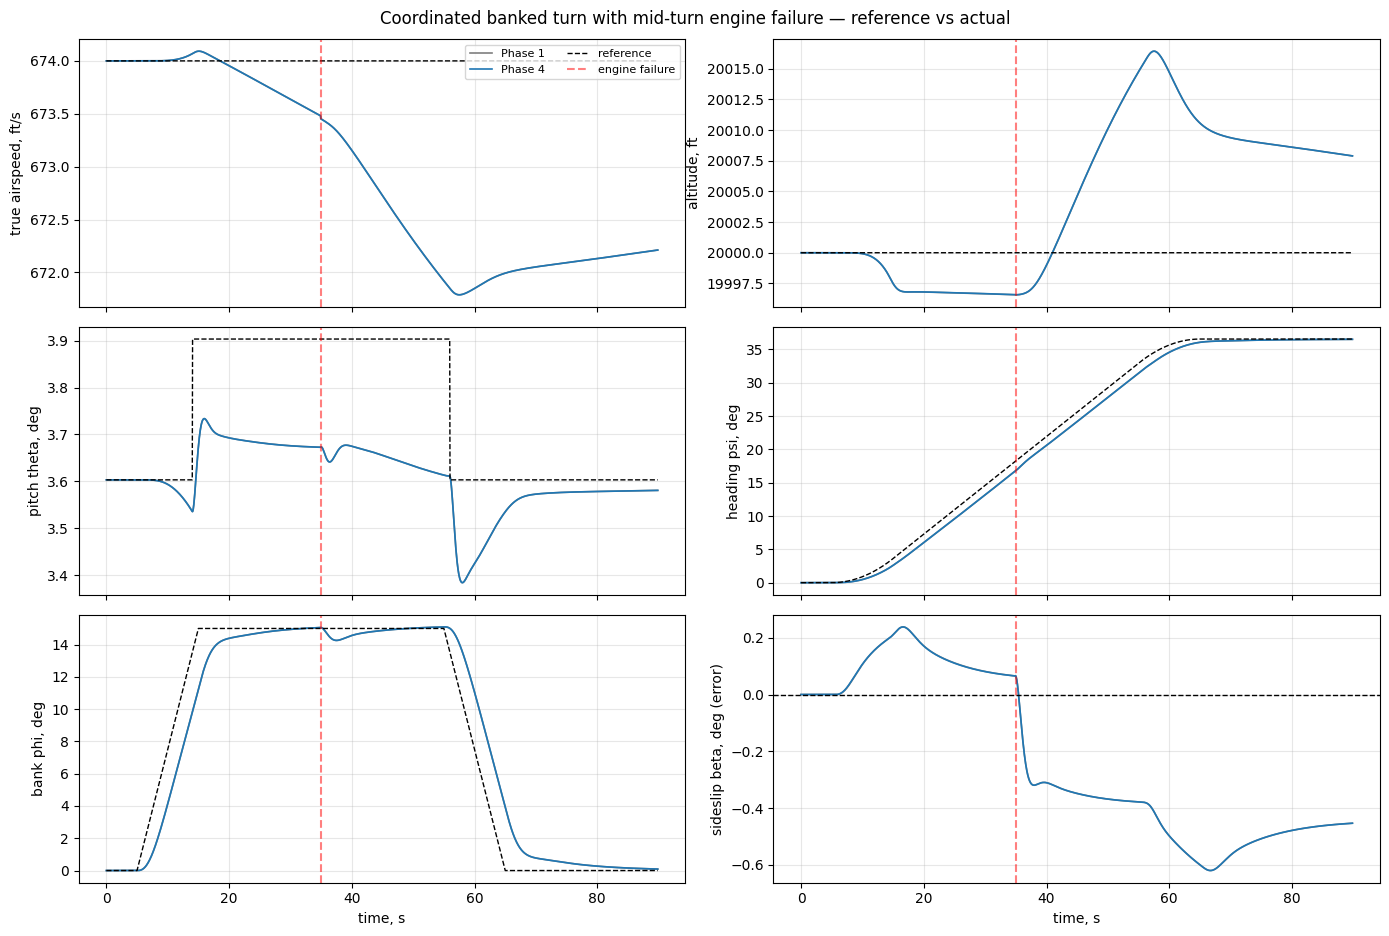

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9.5), sharex=True)
panels = [
    ('V', 'V_actual', 'V_ref', 'true airspeed, ft/s'),
    ('h', 'h_actual', 'h_ref', 'altitude, ft'),
    ('theta', 'theta_actual', 'theta_ref', 'pitch theta, deg'),
    ('psi', 'psi_actual', 'psi_ref', 'heading psi, deg'),
    ('phi', 'phi_actual', 'phi_ref', 'bank phi, deg'),
    ('beta', None, 'beta_ref', 'sideslip beta, deg (error)'),
]
for ax, (key, key_actual, key_ref, ylabel) in zip(axes.flat, panels):
    if key_actual is not None:
        ax.plot(log_p1['t'], log_p1[key_actual], color='tab:gray', lw=1.2, label='Phase 1')
        ax.plot(log_p4['t'], log_p4[key_actual], color='tab:blue', lw=1.2, label='Phase 4')
        ax.plot(log_p4['t'], log_p4[key_ref], color='black', ls='--', lw=1.0, label='reference')
    else:
        # beta — plot the error (actual - reference, both are deg).
        ax.plot(log_p1['t'], log_p1[key], color='tab:gray', lw=1.2, label='Phase 1 beta error')
        ax.plot(log_p4['t'], log_p4[key], color='tab:blue', lw=1.2, label='Phase 4 beta error')
        ax.axhline(0.0, color='black', ls='--', lw=1.0, label='reference (0)')
    ax.axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5, label='engine failure')
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)
axes[2, 0].set_xlabel('time, s'); axes[2, 1].set_xlabel('time, s')
axes[0, 0].legend(loc='upper right', ncol=2, fontsize=8)
fig.suptitle('Coordinated banked turn with mid-turn engine failure — reference vs actual')
plt.tight_layout(); plt.show()


## 10. Control surfaces and throttle

Side-by-side commands. Phase 4's L4 outer adds tiny residual references on top of the envelope allocator's command, so the two traces should largely overlap with localized differences when L4 / macro-actions are most active.


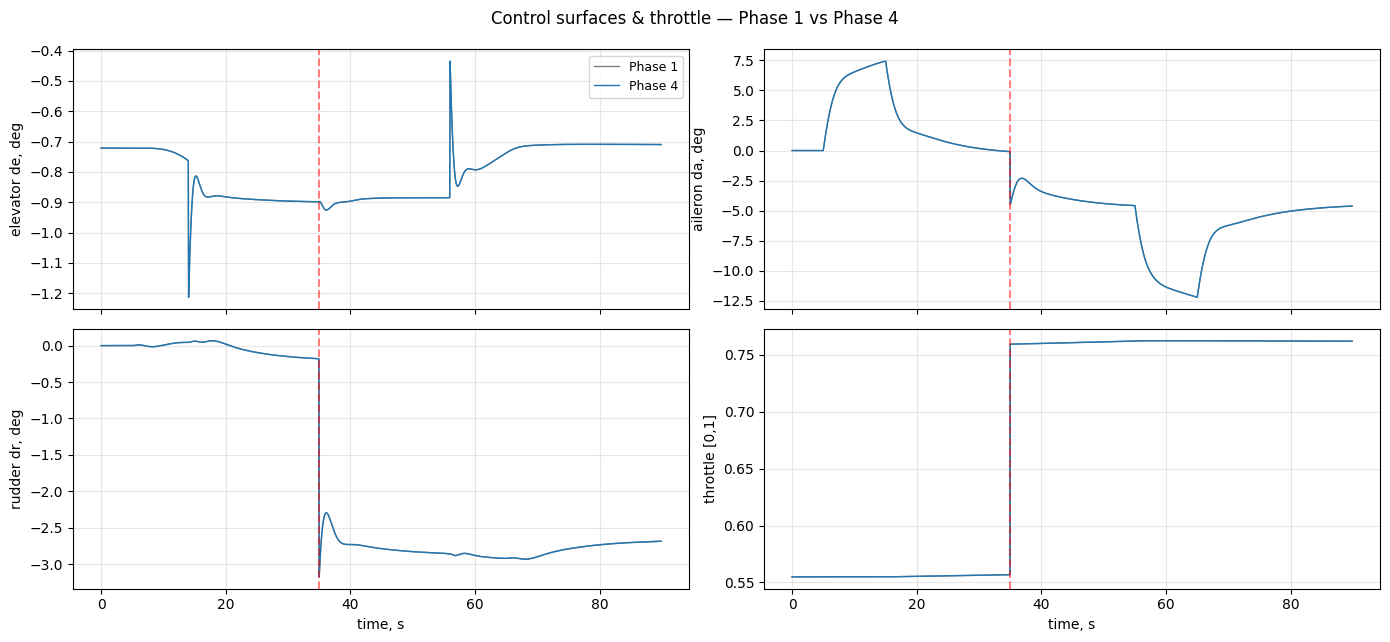

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6.5), sharex=True)
ctrl_panels = [
    ('de', 'elevator de, deg'),
    ('da', 'aileron da, deg'),
    ('dr', 'rudder dr, deg'),
    ('throttle', 'throttle [0,1]'),
]
for ax, (key, ylabel) in zip(axes.flat, ctrl_panels):
    ax.plot(log_p1['t'], log_p1[key], color='tab:gray', lw=1.0, label='Phase 1')
    ax.plot(log_p4['t'], log_p4[key], color='tab:blue', lw=1.0, label='Phase 4')
    ax.axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5)
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)
axes[1,0].set_xlabel('time, s'); axes[1,1].set_xlabel('time, s')
axes[0,0].legend(loc='upper right', fontsize=9)
fig.suptitle('Control surfaces & throttle — Phase 1 vs Phase 4')
plt.tight_layout(); plt.show()


## 11. Composite Lyapunov monitor — V_total and alarm timeline (Phase 4)


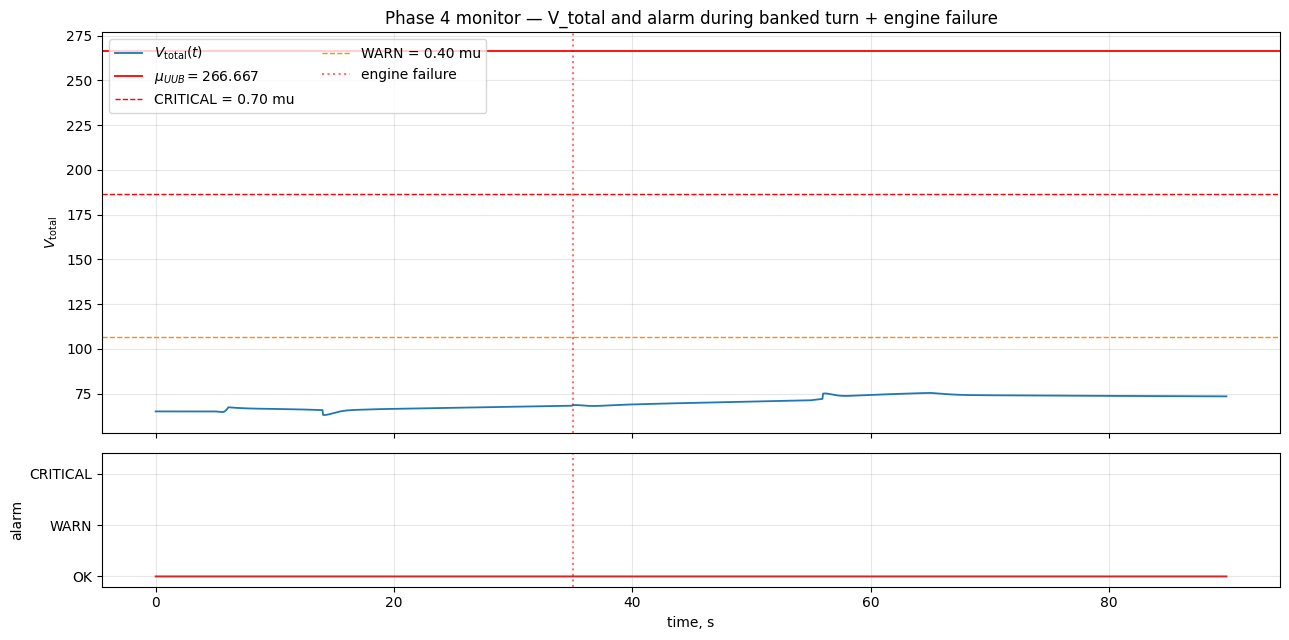

V_total range: [63.007, 75.369], mean = 70.074
Alarm time fractions OK / WARN / CRITICAL: 100.0% / 0.0% / 0.0%
Alarm transitions: 0
Macro-actions fired (total 0):


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
mu_pred = float(ctl_p4.monitor.mu_uub_pred)
warn_th = ctl_p4.cfg.monitor_alarm_warn_frac * mu_pred
crit_th = ctl_p4.cfg.monitor_alarm_critical_frac * mu_pred
axes[0].plot(log_p4['t'], log_p4['V_total'], color='tab:blue', lw=1.3, label=r'$V_{\mathrm{total}}(t)$')
axes[0].axhline(mu_pred, color='red', lw=1.3, label=fr'$\mu_{{UUB}}={mu_pred:.3f}$')
axes[0].axhline(crit_th, color='red', lw=1.0, ls='--',
                label=f'CRITICAL = {ctl_p4.cfg.monitor_alarm_critical_frac:.2f} mu')
axes[0].axhline(warn_th, color='darkorange', lw=1.0, ls='--',
                label=f'WARN = {ctl_p4.cfg.monitor_alarm_warn_frac:.2f} mu')
axes[0].axvline(DAMAGE_TIME, color='red', ls=':', alpha=0.55, label='engine failure')
axes[0].set_ylabel(r'$V_{\mathrm{total}}$'); axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', ncol=2)
axes[1].step(log_p4['t'], log_p4['alarm_level'], color='tab:red', where='post', lw=1.4)
axes[1].axvline(DAMAGE_TIME, color='red', ls=':', alpha=0.55)
axes[1].set_yticks([0,1,2]); axes[1].set_yticklabels(['OK','WARN','CRITICAL'])
axes[1].set_ylim(-0.2, 2.4)
axes[1].set_xlabel('time, s'); axes[1].set_ylabel('alarm')
axes[1].grid(True, alpha=0.3)
axes[0].set_title('Phase 4 monitor — V_total and alarm during banked turn + engine failure')
plt.tight_layout(); plt.show()

alarm_int = log_p4['alarm_level']
ok_frac   = float(np.mean(alarm_int == 0))
warn_frac = float(np.mean(alarm_int == 1))
crit_frac = float(np.mean(alarm_int == 2))
print(f'V_total range: [{float(np.min(log_p4["V_total"])):.3f}, {float(np.max(log_p4["V_total"])):.3f}], '
      f'mean = {float(np.mean(log_p4["V_total"])):.3f}')
print(f'Alarm time fractions OK / WARN / CRITICAL: '
      f'{ok_frac*100:.1f}% / {warn_frac*100:.1f}% / {crit_frac*100:.1f}%')
print(f'Alarm transitions: {len(log_p4["alarm_transitions"])}')
for step_idx, t_, prev, new in log_p4['alarm_transitions'][:20]:
    print(f'  step {step_idx:>5d}, t={t_:>6.2f} s : {prev:>9s} -> {new}')
macro_kinds = Counter(k for _, _, k, _ in log_p4['macro_events'])
print(f'Macro-actions fired (total {len(log_p4["macro_events"])}):')
for k_, v_ in sorted(macro_kinds.items(), key=lambda kv: -kv[1]):
    print(f'  {k_:32s} : {v_} fires')


## 12. Per-engine thrust


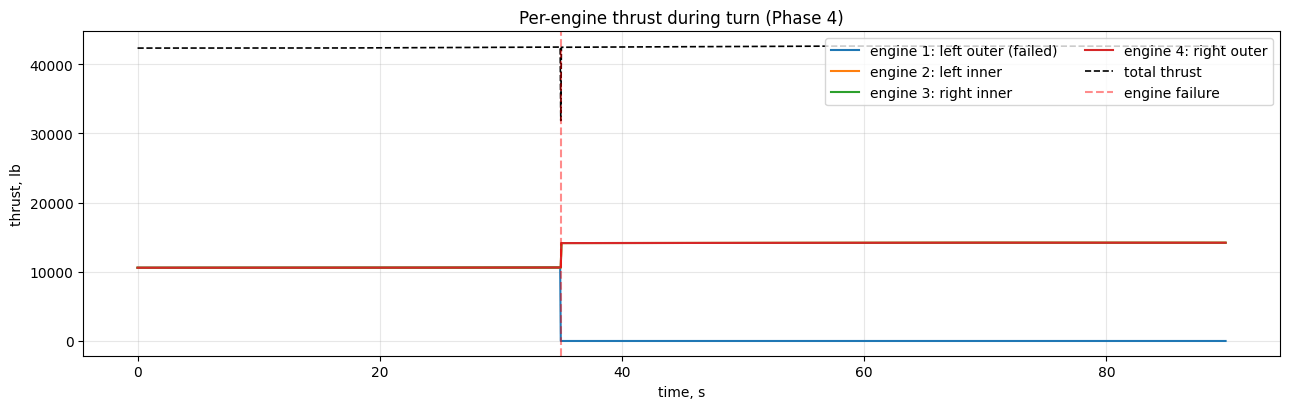

In [13]:
fig, ax = plt.subplots(figsize=(13, 4.2))
labels = {'T1': 'engine 1: left outer (failed)',
          'T2': 'engine 2: left inner',
          'T3': 'engine 3: right inner',
          'T4': 'engine 4: right outer'}
for k_, lab in labels.items():
    ax.plot(log_p4['t'], log_p4[k_], label=lab)
ax.plot(log_p4['t'], log_p4['T_total'], color='black', ls='--', lw=1.2, label='total thrust')
ax.axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.45, label='engine failure')
ax.set_xlabel('time, s'); ax.set_ylabel('thrust, lb')
ax.set_title('Per-engine thrust during turn (Phase 4)')
ax.grid(True, alpha=0.3); ax.legend(loc='upper right', ncol=2)
plt.tight_layout(); plt.show()


## 13. Tracking-error RMS comparison

Quantitative summary in the **post-damage window** `t ∈ [35, 90] s`. We report RMS of the tracking error per channel for both configurations.


In [14]:
post = (log_p4['t'] >= DAMAGE_TIME)
post_p1 = (log_p1['t'] >= DAMAGE_TIME)

def rms(y):
    return float(np.sqrt(np.mean(np.asarray(y, dtype=np.float64) ** 2)))

rows = []
for key, label, unit in [
    ('V', 'speed error', 'ft/s'),
    ('h', 'altitude error', 'ft'),
    ('theta', 'pitch error', 'deg'),
    ('psi', 'heading error', 'deg'),
    ('phi', 'bank error', 'deg'),
    ('beta', 'sideslip error', 'deg'),
]:
    r1 = rms(log_p1[key][post_p1])
    r4 = rms(log_p4[key][post])
    rows.append((label, unit, r1, r4))

print(f'Post-damage RMSE (t ∈ [{DAMAGE_TIME:.0f}, {TOTAL_TIME:.0f}] s)')
print(f'{"channel":<18s}  {"unit":<6s}  {"Phase 1":>10s}  {"Phase 4":>10s}  {"ratio":>7s}')
print('-' * 60)
for label, unit, r1, r4 in rows:
    ratio = r4 / r1 if r1 > 0 else float('nan')
    print(f'{label:<18s}  {unit:<6s}  {r1:>10.4f}  {r4:>10.4f}  {ratio:>7.3f}')

# Final-state summary
print()
print('Final-state summary (last logged sample):')
for tag, log_ in [('Phase 1', log_p1), ('Phase 4', log_p4)]:
    print(f'  {tag}:  V_err={log_["V"][-1]:+8.3f} ft/s, h_err={log_["h"][-1]:+8.2f} ft, '
          f'phi_err={log_["phi"][-1]:+7.3f} deg, psi_err={log_["psi"][-1]:+7.3f} deg')
    print(f'           phi_actual={log_["phi_actual"][-1]:+6.2f} deg, '
          f'psi_actual={log_["psi_actual"][-1]:+6.2f} deg, '
          f'V_actual={log_["V_actual"][-1]:7.2f} ft/s, '
          f'h_actual={log_["h_actual"][-1]:8.1f} ft')


Post-damage RMSE (t ∈ [35, 90] s)
channel             unit       Phase 1     Phase 4    ratio
------------------------------------------------------------
speed error         ft/s        1.7649      1.7651    1.000
altitude error      ft          9.6639      9.6647    1.000
pitch error         deg         0.1715      0.1715    1.000
heading error       deg         0.9864      0.9861    1.000
bank error          deg         1.5363      1.5362    1.000
sideslip error      deg         0.4527      0.4527    1.000

Final-state summary (last logged sample):
  Phase 1:  V_err=  -1.788 ft/s, h_err=   +7.90 ft, phi_err= +0.091 deg, psi_err= -0.042 deg
           phi_actual= +0.09 deg, psi_actual=+36.51 deg, V_actual= 672.21 ft/s, h_actual= 20007.9 ft
  Phase 4:  V_err=  -1.788 ft/s, h_err=   +7.90 ft, phi_err= +0.092 deg, psi_err= -0.042 deg
           phi_actual= +0.09 deg, psi_actual=+36.51 deg, V_actual= 672.21 ft/s, h_actual= 20007.9 ft


## 14. Notes & honest caveats

* **Reference injection point.** UFTC's `reference` argument is held at zero. The maneuver is injected through the *envelope-allocator setpoint* `ref_t` consumed by `uftc_state_transform_dyn` and `state_feedback_action_dyn`. UFTC sees a non-trivial drifting error and the cascade compensates online. This is the cleaner path because (a) it preserves the controller's plant-agnostic interface (no controller-side change to support a maneuver), and (b) the existing engine-out trim blend (`trim_action_for_loss`) lives in the envelope allocator anyway.
* **Damage trigger.** A local `DamageProfile` is built with `EngineFailureEvent(trigger_time=35.0, engine_id=1, thrust_fraction=0.0)`, mirroring the stock `LEFT_OUTER_ENGINE_FAILURE` preset but mid-turn rather than at t=10s.
* **Pre-trained L4 actor mismatch.** The actor in `artifacts/dsac/b747_engine_out_v1/` was trained on the stationary-trim engine-out scenario, *not* on a banked-turn schedule. We expect Phase 4 to be roughly comparable to Phase 1 — possibly slightly worse on yaw because the L4 reference correction is mis-aligned with the maneuver. A curriculum across maneuvers (level cruise + various bank schedules + engine-out at random t) would close that gap; the current demo shows the framework runs end-to-end on a non-stationary task, not that L4 is optimal here.
* **Determinism.** `np.random.seed(0)`, `torch.manual_seed(0)`, `AAINDIConfig(seed=0)`, `l4_seed=0`. The same rollout reproduces bit-for-bit across runs.
* **Coordinated-turn approximation.** Bank φ is set directly via a piecewise-linear schedule; ψ_ref(t) is the trapezoidal integral of the coordinated-turn rate `g·tan(φ)/V`. The aircraft is not constrained to fly a *true* coordinated turn — the controller adapts to whatever (φ_ref, ψ_ref) trajectory we feed it.
